# Pseudo EOF patterns based on GMM

In [1]:
import os
from importlib import reload
import xarray as xr
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy as ctp
import seaborn as sns
from sklearn import mixture, decomposition
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
import cartopy.mpl.ticker as cticker
import cartopy.feature as feature
import matplotlib.ticker as mticker
from datetime import datetime, timedelta
import xesmf as xe

In [2]:
import preproc
import utils
import utenso
import eof
import utdata
import utstats
import metric
import geoplot as gpl
plt.style.use("/home/gsato/latgmm/paper.mplstyle")

In [3]:
ds_pi = xr.open_dataset("/groups/XDU5/Go/research_data/latgmm/sst_pi_500.nc", decode_timedelta=True)
ds_mh = xr.open_dataset("/groups/XDU5/Go/research_data/latgmm/sst_mh_500.nc", decode_timedelta=True)

### 1. interpolate data on a curvilinear grid (i.e. RCM, WRF, NARR) to a rectilinear grid because PCA analysis only handles a rectilinear grid

In [4]:
def regrid(ds):
    
    dr = ds
    
    #1 rename the coordinate names to lon and lat because xESMF has no way to guess variable meaning
    ds = ds.rename({"TLONG": "lon", "TLAT": "lat"})

    #2 regrid it to a global 1deg * 1deg grid 
    #  xESMF provides a shortcut to make this output grid
    #ds_out = xe.util.grid_global(1, 1) # contains lat/lon values of cell centers and boundaries.
    ds_out = xr.Dataset(
    {
        "lat": (["lat"], np.arange(-90, 90, 1.0), {"units": "degrees_north"}),
        "lon": (["lon"], np.arange(-180, 180, 1.0), {"units": "degrees_east"}),
    }
    )

    #3 Regridding
    regridder = xe.Regridder(ds, ds_out, "bilinear")
    dr_out = regridder(dr)
    
    return dr_out

In [5]:
temp_pi_reg = regrid(ds_pi)
temp_mh_reg = regrid(ds_mh)

In [6]:
temp_pi_reg

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 6000, lat: 180, lon: 360)
Coordinates:
    z_t      float32 4B ...
  * time     (time) object 48kB 0401-01-01 00:00:00 ... 0900-12-01 00:00:00
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 86.0 87.0 88.0 89.0
  * lon      (lon) float64 3kB -180.0 -179.0 -178.0 -177.0 ... 177.0 178.0 179.0
Data variables:
    sst      (time, lat, lon) float32 2GB 0.0 0.0 0.0 ... -1.797 -1.797 -1.797
Attributes:
    regrid_method:  bilinear

In [7]:
# selecting the surface layer and the last 500 years

#sst_pi = temp_pi_reg.sel(z_t = 500.0) #selecting depth
#sst_pi_500 = sst_pi.sel(time=slice("0401-01-01 00:00:00", "0900-12-01 00:00:00")) 
#sst_mh = temp_mh_reg.sel(z_t = 500.0)
#sst_mh_500 = sst_mh.sel(time=slice("0401-01-01 00:00:00", "0900-12-01 00:00:00")) 
sst_pi_500 = temp_pi_reg["sst"]
sst_mh_500 = temp_mh_reg["sst"]

In [8]:
# getting climatologies and anomalies

sst_pi_clim = sst_pi_500.groupby('time.month').mean("time")
sst_pi_anom = sst_pi_500.groupby('time.month')-sst_pi_clim

sst_mh_clim = sst_mh_500.groupby('time.month').mean("time")
sst_mh_anom = sst_mh_500.groupby('time.month')-sst_mh_clim

In [9]:
# 6ka has more nan values => more land grid points
print(sst_pi_anom[0,:,:].isnull().sum())
print(sst_mh_anom[0,:,:].isnull().sum())

<xarray.DataArray 'sst' ()> Size: 8B
array(19717)
Coordinates:
    z_t      float32 4B 500.0
    time     object 8B 0401-01-01 00:00:00
    month    int64 8B 1
<xarray.DataArray 'sst' ()> Size: 8B
array(19778)
Coordinates:
    z_t      float32 4B 500.0
    time     object 8B 0401-01-01 00:00:00
    month    int64 8B 1


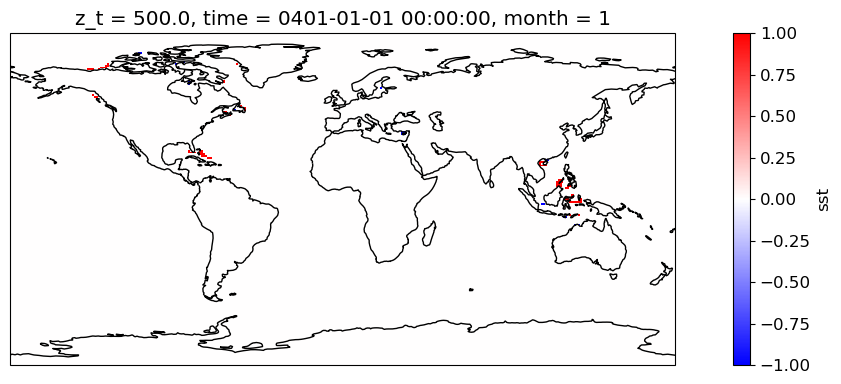

In [10]:
#check the difference in the land-sea mask 
plt.figure(figsize=(12, 4))
ax = plt.axes(projection=ccrs.PlateCarree())
pi_mask = xr.where(sst_pi_anom[0,:,:].isnull(), 0, 1) # sea =>1, nan(land) => 0
mh_mask = xr.where(sst_mh_anom[0,:,:].isnull(), 0, 1)
(pi_mask-mh_mask).plot.pcolormesh(ax=ax, x="lon", y="lat", cmap="bwr")
ax.coastlines()

In [11]:
#making a new dataset

sst_pi_anom = xr.Dataset(
    {
        'ssta': (["time", 'lat', 'lon'], sst_pi_anom[:,:,:].values),
    },
    coords={"time": sst_pi_anom["time"],
        'lat': sst_pi_anom["lat"],   # Latitude coordinates
        'lon': sst_pi_anom["lon"],  # Longitude coordinates
    },
)

sst_mh_anom = xr.Dataset(
    {
        'ssta': (["time", 'lat', 'lon'], sst_mh_anom[:,:,:].values),
    },
    coords={"time": sst_pi_anom["time"],
        'lat': sst_pi_anom["lat"],   # Latitude coordinates
        'lon': sst_pi_anom["lon"],  # Longitude coordinates
    },
)

In [12]:
sst_pi_anom.drop_vars(["z_t"])
sst_mh_anom.drop_vars(["z_t"])

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 6000, lat: 180, lon: 360)
Coordinates:
  * time     (time) object 48kB 0401-01-01 00:00:00 ... 0900-12-01 00:00:00
    month    (time) int64 48kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 86.0 87.0 88.0 89.0
  * lon      (lon) float64 3kB -180.0 -179.0 -178.0 -177.0 ... 177.0 178.0 179.0
Data variables:
    ssta     (time, lat, lon) float32 2GB 0.0 0.0 0.0 ... -0.008779 -0.008754

### 2. Mask out the ocean

In [13]:
#select ocean grid points for both 6ka and pi 
sst_mh_anom_masked = sst_mh_anom.where((pi_mask==1) & (mh_mask==1))
sst_pi_anom_masked = sst_pi_anom.where((pi_mask==1) & (mh_mask==1))

### 4. Sort longitude to 0->180->0 & latitude weight

In [14]:
pi_for_concat = sst_pi_anom_masked
ds_east_pi = pi_for_concat.sel(lon=slice(130, 179))
ds_west_pi = pi_for_concat.sel(lon=slice(-180, -70))
ds_selected_pi = xr.concat([ds_east_pi, ds_west_pi], dim="lon")
ds_selected_pi

<xarray.Dataset> Size: 696MB
Dimensions:  (time: 6000, lat: 180, lon: 161)
Coordinates:
    z_t      (time) float32 24kB 500.0 500.0 500.0 500.0 ... 500.0 500.0 500.0
  * time     (time) object 48kB 0401-01-01 00:00:00 ... 0900-12-01 00:00:00
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 86.0 87.0 88.0 89.0
  * lon      (lon) float64 1kB 130.0 131.0 132.0 133.0 ... -72.0 -71.0 -70.0
Data variables:
    ssta     (time, lat, lon) float32 696MB 0.0 0.0 0.0 ... 0.002241 0.002293

In [15]:
mh_for_concat = sst_mh_anom_masked
ds_east_mh = mh_for_concat.sel(lon=slice(130, 179))
ds_west_mh = mh_for_concat.sel(lon=slice(-180, -70))
ds_selected_mh = xr.concat([ds_east_mh, ds_west_mh], dim="lon")
ds_selected_mh

<xarray.Dataset> Size: 696MB
Dimensions:  (time: 6000, lat: 180, lon: 161)
Coordinates:
    z_t      (time) float32 24kB 500.0 500.0 500.0 500.0 ... 500.0 500.0 500.0
  * time     (time) object 48kB 0401-01-01 00:00:00 ... 0900-12-01 00:00:00
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 86.0 87.0 88.0 89.0
  * lon      (lon) float64 1kB 130.0 131.0 132.0 133.0 ... -72.0 -71.0 -70.0
Data variables:
    ssta     (time, lat, lon) float32 696MB 0.0 0.0 0.0 ... -0.007747 -0.007777

In [16]:
# weight the SSTA by latitudes

def weight_sst_anomalies(data):
    """
    Applies latitude-based weighting to SST anomalies using the square root of the cosine of latitude.

    Parameters:
    - sst_anomalies (numpy array): 2D or 3D array of SST anomalies (time, lat, lon).
    - latitudes (numpy array): 1D array of latitudes corresponding to SST data.

    Returns:
    - weighted_sst (numpy array): SST anomalies weighted by sqrt(cos(latitude)).
    """
    # Convert latitudes to radians
    lat_radians = np.deg2rad(data["lat"].values)
    
    # Compute the weighting factor (sqrt(cos(lat)))
    weights = np.sqrt(np.cos(lat_radians))
    
    # Expand dimensions to match SST anomaly array (for broadca
    weight_matrix = xr.DataArray(weights,dims=["lat"])
    
    weighted_sst = data *weight_matrix

    return weighted_sst

sst_pi_anom_sorted_weighted = weight_sst_anomalies(ds_selected_pi) #sst_pi_anom_sorted
sst_mh_anom_sorted_weighted = weight_sst_anomalies(ds_selected_mh) #sst_mh_anom_sorted

### 5. Project 6ka SSTA onto PCs from piControl

In [17]:
def project_sst_to_eofs(data1,data2,pc_components):
    ##################################################################
    # This is the function to project data2 onto EOFs obtained from data1
    # data1 and data2 should have variables called ssta
    # pc_components: the number of PCs to be used for the projection 
    ##################################################################
    import numpy as np
    from numpy import linalg as LA
    from sklearn.decomposition import PCA
    ##################################################################
    
    ds4eof_pi = data1
    #idx_notNaN_pi = np.ma.masked_invalid(ds4eof_pi["ssta"]).filled(0.) # replace NaN values with 0
    #idx_notNaN_pi = (idx_notNaN_pi - idx_notNaN_pi.mean())/idx_notNaN_pi.std() # standardize the anomalies
    #nt, ny, nx = idx_notNaN_pi.shape
    #X_pi = np.reshape(idx_notNaN_pi, (nt, ny*nx))            # reduce 3-D to 2-D
    #X_pi_mean = X_pi.mean(axis=0)                         # Mean over all timesteps
    #C_pi = np.cov(X_pi, rowvar=False)                     # calculate covariance matrix
    #eigenvalues_pi, eigenvectors_pi=LA.eig(C_pi)          # get eigenvalues and eigenvectors
    #idx = eigenvalues_pi.argsort()[::-1]                  # Sorts the indices of the matrix 
    #eigenvectors_pi = eigenvectors_pi[:,idx]                # based on the magnitudes of the eigenvalues
    #eigenvectors_pi[:,1] = -eigenvectors_pi[:,1]
    #PC_pi = np.dot(X_pi - X_pi_mean, eigenvectors_pi[:,0:pc_components])   # the number of PCs should be identical for PC and 6ka
    sppca = eof.SpatioTemporalPCA(ds4eof_pi, n_components=pc_components)
    ##################################################################

    ds4eof_mh = data2
    #idx_notNaN_mh = np.ma.masked_invalid(ds4eof_mh["ssta"]).filled(0.)
    #idx_notNaN_mh = (idx_notNaN_mh - idx_notNaN_mh.mean())/idx_notNaN_mh.std() # standardize the anomalies
    #nt_, ny_, nx_ = idx_notNaN_mh.shape
    #X_mh = np.reshape(idx_notNaN_mh, (nt_, ny_*nx_))
    #X_mh_centered = np.empty(shape=(len(X_mh[:,0]), len(X_mh[0,:])), dtype=np.float64)
    #X_mh_centered = np.where(X_mh != 0, X_mh - X_pi_mean, 0)
    
    return sppca, sppca.transform(ds4eof_mh)
    #PC_mh = np.dot(X_mh_centered, eigenvectors_pi[:,0:pc_components])        
    # PCs in piControl and pseudo-PCs in 6ka  
    #PC_mh = X_mh・eigenvectors_pi
    #return PC_pi, PC_mh

In [18]:
PC_pi, PC_mh = project_sst_to_eofs(sst_pi_anom_sorted_weighted.sel(lat=slice(-31,33)),
                                   sst_mh_anom_sorted_weighted.sel(lat=slice(-31,33)),
                                   2)

### skip the next 2 cells

In [27]:
print(PC_pi.get_principal_components().shape)
print(PC_pi.explained_variance())
print(np.sum(PC_pi.explained_variance()))

(6000, 4)
[0.52583182 0.11238834 0.055184   0.03288003]
0.7262841918972368


([<matplotlib.axis.XTick at 0x7faebb4b8510>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10')])

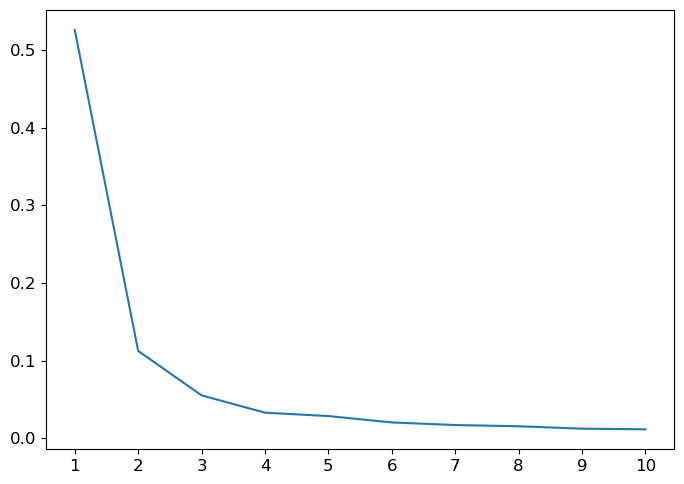

In [22]:
# plot the first 10 PC components
plt.plot(np.arange(1,11), PC_pi.explained_variance())
plt.xticks(np.arange(1,11))

### 6. Make PCs data

In [19]:
PC_pi_st = PC_pi.get_principal_components()
PC_mh_st = xr.DataArray(PC_mh,
    dims=["time", "eof"],
    coords={"time": PC_pi_st["time"], "eof": PC_pi_st["eof"]},
)

Text(0.5, 1.0, '6ka')

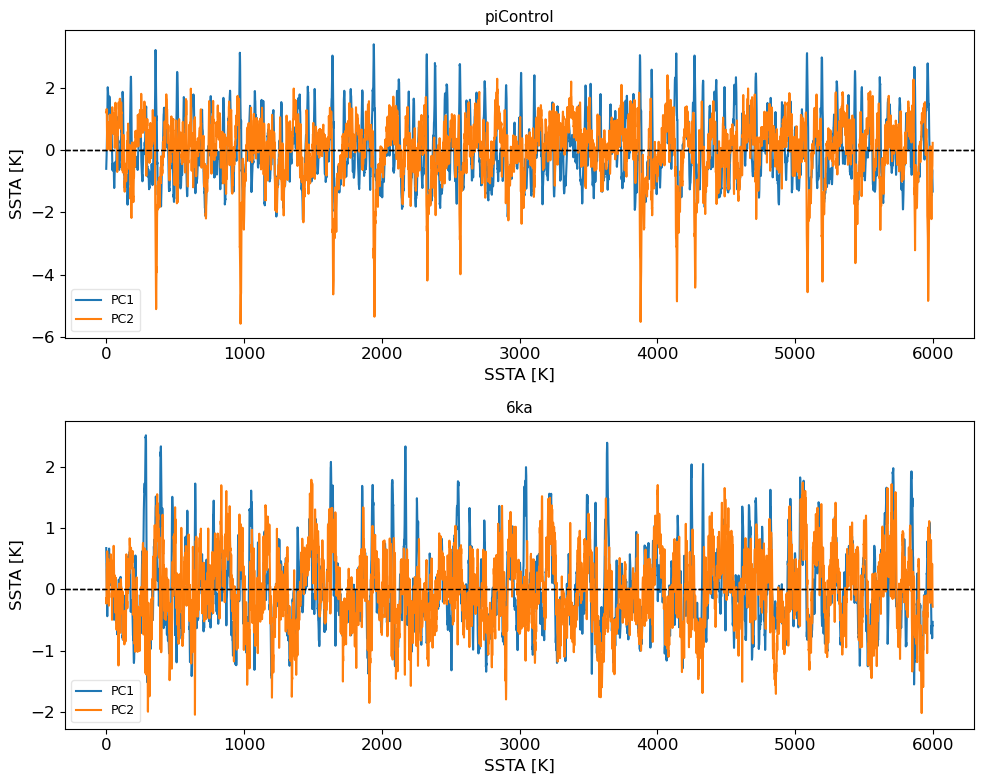

In [26]:
# draw PC time series

fig, ax = plt.subplots(nrows=2,ncols=1, figsize=(10,8))
ax = ax.flatten()

for i in np.arange(0,2):
    #standardize PC time series
    #PC_pi_st = (PC_pi[:,i] - np.mean(PC_pi[:,i]))/np.std(PC_pi[:,i])
    ax[0].plot(PC_pi_st[:,i], label=f"PC{i+1}")#PC_pi_st[:,i]
    ax[0].axhline(0, color='black', linestyle='--', linewidth=1)
    ax[1].plot(PC_mh_st[:,i], label=f"PC{i+1}")#/np.std(PC_mh[:,i])
    ax[1].axhline(0, color="black", linestyle="--", linewidth=1)

ax[0].set_ylabel("SSTA [K]")   
ax[1].set_ylabel("SSTA [K]")    
ax[0].set_xlabel("SSTA [K]")   
ax[1].set_xlabel("SSTA [K]")
ax[0].legend(loc="lower left", fontsize=9)  
ax[1].legend(loc="lower left", fontsize=9)             
ax[0].set_title("piControl", fontsize=11)
ax[1].set_title("6ka", fontsize=11)
#plt.savefig("/home/gsato/latgmm/figures/PCs_timeseries_200_SSTA.pdf")

/tmp/ipykernel_1018392/2872212107.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig("/home/gsato/latgmm/figures/PCs_spatialpatterns_200_SSTA.pdf")
/tmp/ipykernel_1018392/2872212107.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig("/home/gsato/latgmm/figures/PCs_spatialpatterns_200_SSTA.pdf")
/home/gsato/miniforge/envs/pyn_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


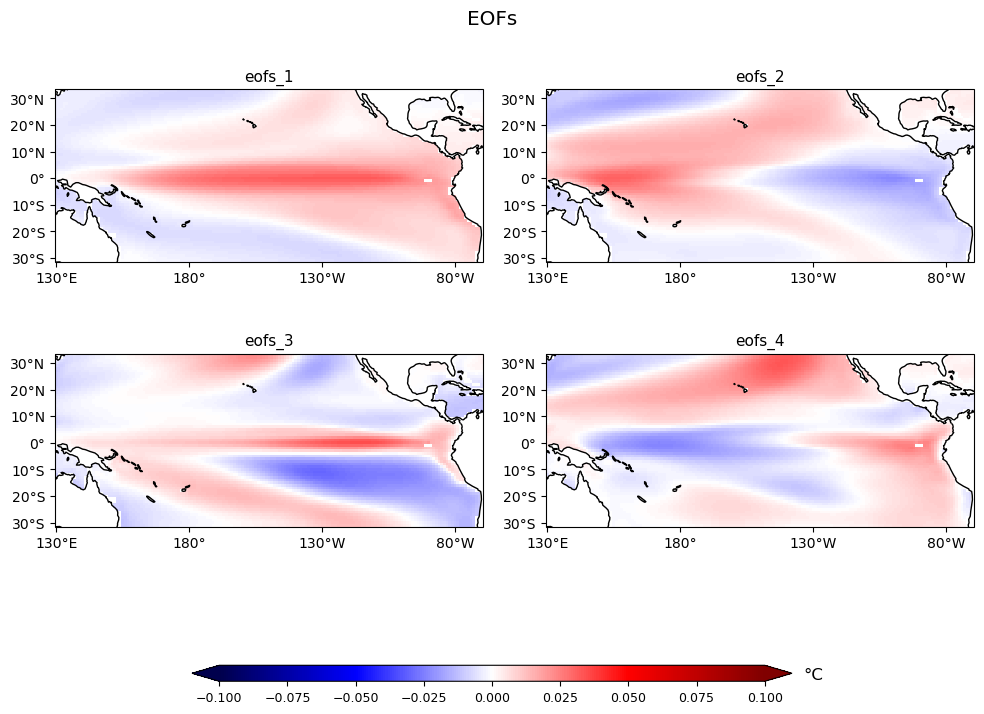

In [27]:
# plot spatial patterns

eofs = PC_pi.get_eofs()
clevs = np.arange(-0.1,0.101,0.005)
pc_components = 4
fig, ax = plt.subplots(nrows=2,ncols=2, figsize=(10,8),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
ax = ax.flatten()
for i in np.arange(0,pc_components):
    #data,lons = add_cyclic_point(eofs.sel(eof=i)["ssta"],coord=eofs["lon"])
    cs = ax[i].pcolormesh(eofs["lon"].data, eofs["lat"].data, eofs.sel(eof=i)["ssta"], 
                                  transform=ccrs.PlateCarree(), 
                                  vmin=clevs.min(), vmax=clevs.max(),
                                  cmap='seismic')#add_bar=False)#, **plparam)
    ax[i].set_title(f"eofs_{i+1}", fontsize=11)   
    #longitude labels
    ax[i].set_xticks(np.arange(130,291,50), crs=ccrs.PlateCarree())
    ax[i].tick_params(axis='x', rotation=0, labelsize=10)
    lon_formatter = cticker.LongitudeFormatter()
    ax[i].xaxis.set_major_formatter(lon_formatter)
    # Latitude labels
    ax[i].set_yticks(np.arange(-30,31,10), crs=ccrs.PlateCarree())
    ax[i].tick_params(axis='y', rotation=0, labelsize=10)
    lat_formatter = cticker.LatitudeFormatter()
    ax[i].yaxis.set_major_formatter(lat_formatter)
    #coastlines
    ax[i].coastlines()

# Adjust the location of the subplots 
# on the page to make room for the colorbar
fig.subplots_adjust(bottom=None, top=None, left=0.05, right=0.95,
                wspace=0.2, hspace=0.5)
# Add a colorbar axis at the bottom of the graph
cbar_ax = fig.add_axes([0.2, 0.01, 0.6, 0.02])
# Draw the colorbar
cbar=fig.colorbar(cs, cax=cbar_ax,orientation='horizontal',label=None,extend="both")
#cbar.ax.set_aspect(0.01)
cbar_ax.tick_params(labelsize=9) 
cbar_ax.text(1.07,0.1,"\u00b0C", transform=cbar.ax.transAxes)
# Add a big title at the top
fig.suptitle("EOFs", y=0.85)
plt.savefig("/home/gsato/latgmm/figures/PCs_spatialpatterns_200_SSTA.pdf")

### 7. Get ENSO events

In [20]:
reload(utenso)
month_range = [12, 1]
sst_pi_anom_sorted_weighted = sst_pi_anom_sorted_weighted.assign_coords(member=('time', ['piControl']*len(sst_pi_anom_sorted_weighted.time)))
sst_mh_anom_sorted_weighted = sst_mh_anom_sorted_weighted.assign_coords(member=('time', ['piControl']*len(sst_mh_anom_sorted_weighted.time)))

x_enso, x_events = utenso.select_enso_events(sst_pi_anom_sorted_weighted.sel(lat=slice(-31,33)), 
                                             month_range=month_range, threshold=0.5)
print("iCESM complete")            
x_enso_mh, x_events_mh = utenso.select_enso_events(sst_mh_anom_sorted_weighted.sel(lat=slice(-31,33)), 
                                                   month_range=month_range, threshold=0.5) 
print("iCESM_6ka complete")    

iCESM complete
iCESM_6ka complete


In [29]:
# piControl

pcgmm_storer = {}

z_enso_da = PC_pi_st.sel(time=x_enso.time)

data = xr.DataArray()

def get_djf_season_year(time):
    return time.dt.year.where(~time.dt.month.isin([1, 2]), time.dt.year - 1)

# Assign the new season-year as a coordinate
data = z_enso_da.assign_coords(time=get_djf_season_year(z_enso_da.time))

# Group by DJF season-year and take the mean
z_events_da = data.groupby("time").mean("time")
z_events_da["time"] = x_events["time"]

pcgmm_storer["iCESM"] = dict(
        z_enso=z_enso_da,
        z_events=z_events_da,)

In [30]:
# 6ka
z_enso_da_mh = PC_mh_st.sel(time=x_enso_mh.time)

data = xr.DataArray()

def get_djf_season_year(time):
    return time.dt.year.where(~time.dt.month.isin([1, 2]), time.dt.year - 1)

# Assign the new season-year as a coordinate
data = z_enso_da_mh.assign_coords(time=get_djf_season_year(z_enso_da_mh.time))

# Group by DJF season-year and take the mean
z_events_da_mh = data.groupby("time").mean("time")
z_events_da_mh["time"] = x_events_mh["time"]

pcgmm_storer["iCESM_6ka"] = dict(
        z_enso=z_enso_da_mh,
        z_events=z_events_da_mh,)

### 8. GMM scan

In [31]:
def bic(gmm, X, n_additional_parameters=0):
    """ Bayesian Information Criterion for GMMs including additional parameters.

    Args: 
        gmm (sklearn.mixture.GaussianMixture): The GMM to compute the BIC for.
        X (np.ndarray): The input samples of shape (n_samples, n_dimensions).
    
    Returns:
        bic (float) : The lower the better.
    """
    n_parameters = gmm._n_parameters() + n_additional_parameters
    return -2 * gmm.score(X) * X.shape[0] + n_parameters * np.log(X.shape[0])

eof_projections = ["iCESM", "iCESM_6ka"]
n_classes = np.arange(2, 9, 1)
n_runs = 250
z_enso = pcgmm_storer["iCESM"]['z_enso']
result = []
for k in n_classes:
    for r in range(n_runs):
        gmm = mixture.GaussianMixture(n_components=k, 
                                      covariance_type='full', max_iter=n_runs)
        gmm.fit(z_enso.data)
        result.append(
            {'k': k, 'bic': bic(gmm, z_enso.data, n_additional_parameters=0), 'gmm': gmm}
        )
pcgmm_storer["iCESM"]['gmm_scan'] = pd.DataFrame(result)

### 9. Store probability memberships

In [32]:
# piControl

gmm_scan = pcgmm_storer['iCESM']['gmm_scan'] 
#gmm = gmm_scan.loc[gmm_scan['bic'].idxmin()]['gmm']
f = gmm_scan.loc[gmm_scan['k'] == 5]
gmm = f.loc[f["bic"].idxmin()]["gmm"]
gmm_order = np.argsort(gmm.means_[:, 0])[::-1]

z_enso = pcgmm_storer['iCESM']['z_enso']
z_events = pcgmm_storer['iCESM']['z_events']
# Event weights
p_c_given_x = utenso.posterior_weights(
    z_enso.data, means=gmm.means_, covariances=gmm.covariances_,
    prior_weights=gmm.weights_
)
# convert to xarray
p_c_given_x_da = xr.DataArray(data=p_c_given_x, dims=['time', 'classes'], 
                              coords={ 
                                'time': np.array(z_enso['time'].data), #dtype='datetime64[M]'),
                                'member': ('time', z_enso['member'].data),
                                'classes': np.arange(p_c_given_x.shape[1]) + 1
                              },
                              attrs={'gmm_sort': gmm_order})

In [33]:
# 6ka

# Project the 6ka SST data onto the trained GMM by piControl data

# Soft assignments (posterior probabilities)
X_test_pca = pcgmm_storer["iCESM_6ka"]['z_enso'].data
responsibilities = gmm.predict_proba(X_test_pca)  # Shape (n_samples, n_components)

# Compute the expected mean for the second dataset
expected_means = np.dot(responsibilities.T, X_test_pca) / responsibilities.sum(axis=0)[:, None]

expected_covariances = np.zeros_like(gmm.covariances_)

# Compute the expected covariances for the second dataset
for k in range(gmm.n_components):
    X_centered = X_test_pca - expected_means[k]
    gamma_k = responsibilities[:, k][:, np.newaxis]  # Expand dims for broadcasting
    expected_covariances[k] = (gamma_k * X_centered).T @ X_centered / gamma_k.sum()
    
# Compute the expected weights for the second dataset
expected_weights = responsibilities.mean(axis=0)  # Shape (n_components,)
    
gmm_order_mh = np.argsort(expected_means[:, 0])[::-1]
    
z_enso_mh = pcgmm_storer['iCESM_6ka']['z_enso']
z_events_mh = pcgmm_storer['iCESM_6ka']['z_events']

# Event weights
p_c_given_x_mh = utenso.posterior_weights(
    z_enso_mh.data, means=expected_means, covariances=expected_covariances,
    prior_weights=expected_weights
)
# convert to xarray
p_c_given_x_da_mh = xr.DataArray(data=p_c_given_x_mh, dims=['time', 'classes'], 
                              coords={ 
                                'time': np.array(z_enso_mh['time'].data), #dtype='datetime64[M]'),
                                'member': ('time', z_enso_mh['member'].data),
                                'classes': np.arange(p_c_given_x_mh.shape[1]) + 1
                              },
                              attrs={'gmm_sort': gmm_order_mh})

### 10. Spatial patterns

In [34]:
def plot_gaussians(gmm, ax, gmm_order=None, 
                   gmclrs=['maroon', 'darkorange', 'gold', 'lightblue', 'darkblue', 'black'],
                   alpha=0.5):
    """ Plot the Gaussian components of a Gaussian Mixture Model.
    """
    class_names = ['Extreme El Niño', 'CP El Niño', 'CP La Niña', 'Basin-wide La Niña', ""]
    
    if gmm_order is None:
        gmm_order = np.arange(gmm.n_components)

    for i, k in enumerate(gmm_order):
        mean = gmm.means_[k, :]
        if gmm.covariance_type == "full":
            Sigma = gmm.covariances_[k, :]
        elif gmm.covariance_type == "diag":
            Sigma = np.diag(gmm.covariances_[k, :])

        gmkwargs= dict(fill=False)
        if gmclrs is not None:
            gmkwargs['edgecolor'] = 'k' #gmclrs[i] 
            gmkwargs['facecolor'] = gmclrs[i] 
            gmkwargs['fill'] = True
            gmkwargs['alpha'] = alpha

        for p in [0.7, 0.4, 0.1]:
            if p==0.1:
                gmkwargs['label'] = class_names[i]#rf"$c_{k}$"
            gpl.plot_2dgaussian(mean, Sigma,
                                 ax=ax, p=p, **gmkwargs)
    return ax

### 11. BIC and Latent space

Text(0.5, 1.0, 'BIC')

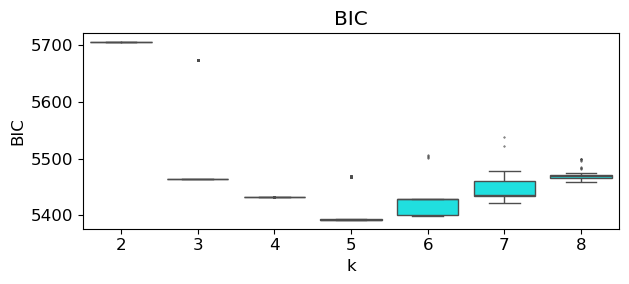

In [35]:
reload(gpl)
#storer = pcgmm_storer[projection]
n_clusters = 4 
#np.max([
#    storer['gmm_scan']['k'].unique()[np.argmin([storer['gmm_scan'].loc[storer['gmm_scan']['k']==k]['bic'].mean() for k in storer['gmm_scan']['k'].unique()])]
#    for storer in pcgmm_storer.values()
#])
nrows, ncols = (n_clusters-3, len(eof_projections))
axs = np.empty((nrows, ncols), dtype=object)
fig = plt.figure(figsize=(ncols*6, nrows*3.))
height_ratio = [1]*nrows
#height_ratio[1] = 1
gs = gridspec.GridSpec(nrows, ncols,
                       height_ratios=height_ratio)

proj = ctp.crs.PlateCarree(central_longitude=180)
plparam = {'ssta': dict(vmin=-2, vmax=2, step=0.1, cmap='RdBu_r', centercolor="#ffffff"),
           'ssha': dict(vmin=-.15, vmax=.15, step=0.025,cmap='RdGy_r', centercolor="#ffffff")}
titles = ['pi','6ka']

#mean = [eofs_pi_map, eofs_mh_map]
correct = [gmm.means_, expected_means]
storer = pcgmm_storer[eof_projections[0]]
# Plot BIC
idx = 0 #n + 1  
ax = fig.add_subplot(gs[idx,0])
axs[idx,0] = ax
ax = sns.boxplot(data=pcgmm_storer["iCESM"]['gmm_scan'], x='k', y='bic', ax=ax,
                 color='cyan', fliersize=0.5)
ax.set_ylabel("BIC")
ax.set_title("BIC")
#plt.savefig("/home/gsato/latgmm/figures/BIC_200_SST_no_34.pdf")

array([<Axes: title={'center': 'piControl'}, xlabel='PC1', ylabel='PC2'>,
       <Axes: title={'center': '6ka'}, xlabel='PC1', ylabel='PC2'>, None,
       None], dtype=object)

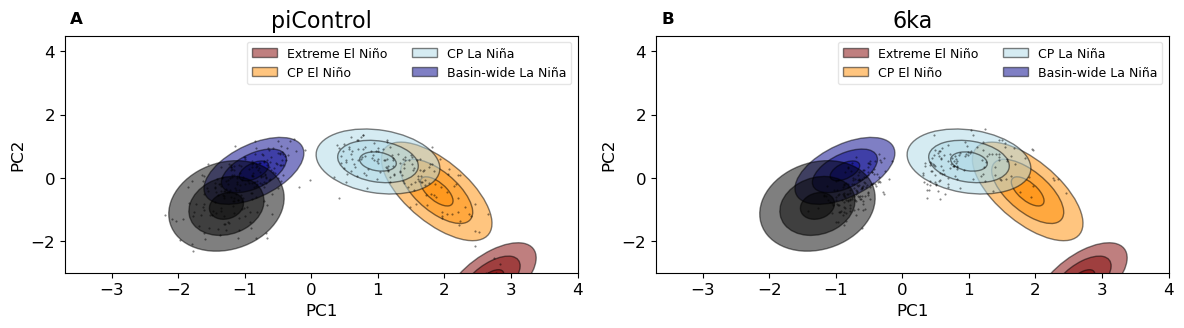

In [36]:
reload(gpl)
#storer = pcgmm_storer[projection]
n_clusters = 5 
#np.max([
#    storer['gmm_scan']['k'].unique()[np.argmin([storer['gmm_scan'].loc[storer['gmm_scan']['k']==k]['bic'].mean() for k in storer['gmm_scan']['k'].unique()])]
#    for storer in pcgmm_storer.values()
#])
nrows, ncols = (n_clusters-3, len(eof_projections))
axs = np.empty((nrows, ncols), dtype=object)
fig = plt.figure(figsize=(ncols*6, nrows*3.))
height_ratio = [1]*nrows
#height_ratio[1] = 1
gs = gridspec.GridSpec(nrows, ncols,
                       height_ratios=height_ratio)

proj = ctp.crs.PlateCarree(central_longitude=180)
plparam = {'ssta': dict(vmin=-2, vmax=2, step=0.1, cmap='RdBu_r', centercolor="#ffffff"),
           'ssha': dict(vmin=-.15, vmax=.15, step=0.025,cmap='RdGy_r', centercolor="#ffffff")}
titles = ['piControl','6ka']

#mean = [eofs_pi_map, eofs_mh_map]
correct = [gmm.means_, expected_means]
for i, projection in enumerate(eof_projections):
    storer = pcgmm_storer[projection]
    # Plot Latent Space
    idx = 0
    ax = fig.add_subplot(gs[idx,i])
    axs[idx,i] = ax
    z_events = storer['z_events']
    markersize = 3 if i == 2 else 1
    alpha = 1 if i == 2 else 0.5
    ax.plot(z_events.isel(eof=0), z_events.isel(eof=1), '.', color='k', markersize=markersize, alpha=alpha)
    #ax.set_ylabel('BIC')

    # Gaussians
    gmm_scan = pcgmm_storer["iCESM"]['gmm_scan']
    #gmm = gmm_scan.loc[gmm_scan['bic'].idxmin()]['gmm']
    f = gmm_scan.loc[gmm_scan['k'] == 5]
    gmm = f.loc[f["bic"].idxmin()]["gmm"]
    gmm_order = np.argsort(gmm.means_[:, 0])[::-1]
    gmclrs=['maroon', 'darkorange', 'lightblue', 'darkblue', 'black', 'darkgreen', 'magenta', 'gold']
    plot_gaussians(gmm, ax, gmm_order=gmm_order, gmclrs=gmclrs, alpha=0.5) 
    ax.legend(ncol=2, fontsize=9,loc=1)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_ylim(-3, 4.5)
    ax.set_xlim(-3.7, 4)
    
    axs[0,i].set_title(titles[i], size=16)
    
gpl.enumerate_subplots(axs.flatten(), pos_x=0.01, pos_y=1.05, fontsize=12)
#plt.savefig("/home/gsato/latgmm/figures/latentspace_200_SST_no_34.pdf")

/home/gsato/miniforge/envs/pyn_env/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'add_colorbar'
  result = super().contourf(*args, **kwargs)
/home/gsato/miniforge/envs/pyn_env/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'add_colorbar'
  result = super().contourf(*args, **kwargs)
/home/gsato/miniforge/envs/pyn_env/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'add_colorbar'
  result = super().contourf(*args, **kwargs)
/home/gsato/miniforge/envs/pyn_env/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'add_colorbar'
  result = super().contourf(*args, **kwargs)
/home/gsato/miniforge/envs/pyn_env/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by cont

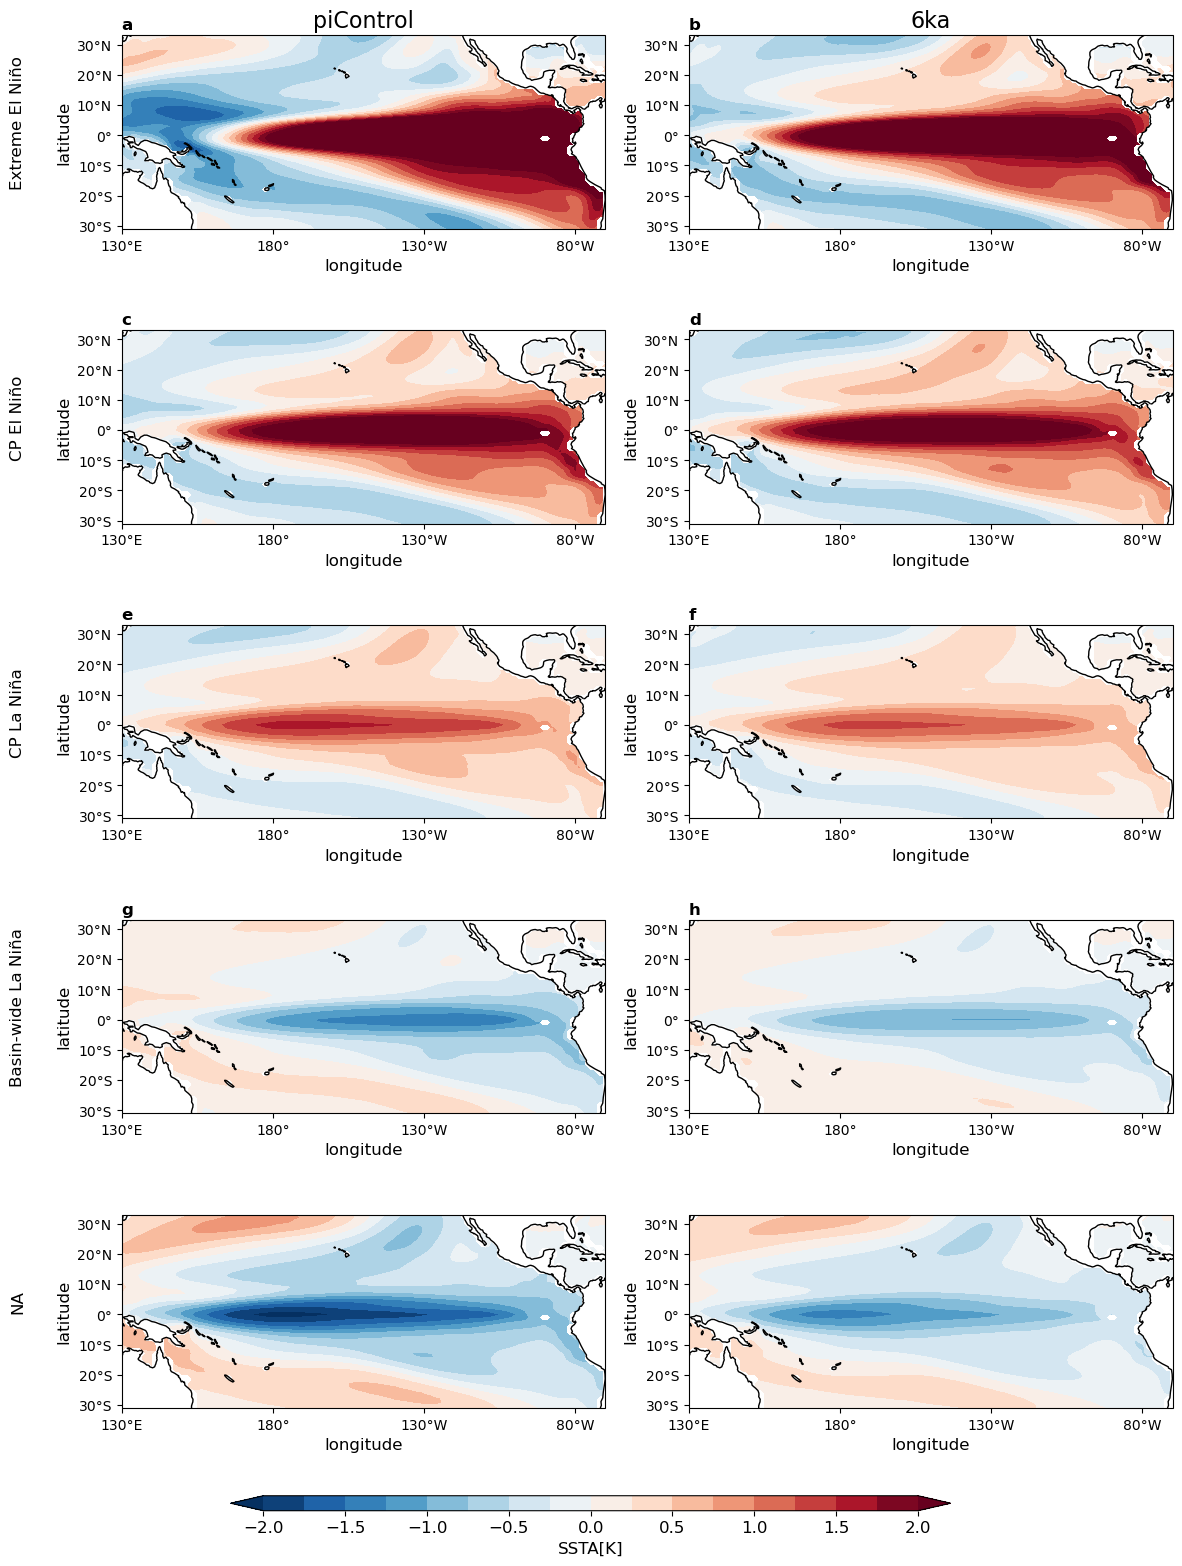

In [37]:
reload(gpl)
#storer = pcgmm_storer[projection]
n_clusters = 5 
#np.max([
#    storer['gmm_scan']['k'].unique()[np.argmin([storer['gmm_scan'].loc[storer['gmm_scan']['k']==k]['bic'].mean() for k in storer['gmm_scan']['k'].unique()])]
#    for storer in pcgmm_storer.values()
#])
class_names = ['Extreme El Niño', 'CP El Niño', 'CP La Niña', 'Basin-wide La Niña',"NA"]
nrows, ncols = (n_clusters, len(eof_projections))
axs = np.empty((nrows, ncols), dtype=object)
fig = plt.figure(figsize=(ncols*6, nrows*3.))
height_ratio = [1]*nrows
height_ratio[1] = 1
clevs = np.arange(-2.0,2.25,0.25)
cmap = 'RdBu_r'
gs = gridspec.GridSpec(nrows, ncols,
                       height_ratios=height_ratio)

proj = ctp.crs.PlateCarree(central_longitude=180)
plparam = {'ssta': dict(vmin=-2, vmax=2, step=0.1, cmap='RdBu_r', centercolor="#ffffff"),
           'ssha': dict(vmin=-.15, vmax=.15, step=0.025,cmap='RdGy_r', centercolor="#ffffff")}
titles = ['piControl','6ka']

#mean = [eofs_pi_map, eofs_mh_map]
correct = [gmm.means_, expected_means]
for i, projection in enumerate(eof_projections):
    storer = pcgmm_storer[projection]
    idx = 0 #n + 1  

    # Plot GMM means
    correct_ = correct[i]
    means = PC_pi.inverse_transform(correct_, newdim='mu')
    #means = mean[i]
    
    if 'normalizer' in ds_selected_mh['ssta'].attrs.keys():
        means = ds_selected_mh['ssta'].attrs['normalizer'].inverse_transform(means['ssta'])
    for n, k in enumerate(gmm_order):
        mu = means.sel(mu=k)
        idx = n 
        ax = fig.add_subplot(gs[idx,i], projection=proj)
        axs[idx,i] = ax
        #im = gpl.plot_map(mu['ssta'], ax=ax, #central_longitude=180, 
        #                  bar='discrete', add_bar=False, **plparam['ssta'])
        #im['gl'].top_labels = False 
        da_reg = mu["ssta"]
        da_reg = da_reg.sortby("lat")
        lon_test = ((da_reg["lon"]+ 360) % 360)
        da_reg = da_reg.assign_coords(lon=lon_test)#da_reg.sortby("lon")
        #cs = da_reg.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), 
        #                            cmap=cmap, add_colorbar=False, vmin=-2.5, vmax=2.5) 
        #cs = da_reg.plot.contourf(ax=ax, transform=ccrs.PlateCarree(),
        #                          cmap=cmap, add_colorbar=False, levels=clevs, extend="both")
        #data = da_reg
        # Add the cyclic point
        #data,lons = add_cyclic_point(data,coord=da_reg['lon'])
        cs = ax.contourf(da_reg.lon, da_reg.lat, da_reg, transform=ccrs.PlateCarree(),
                                  cmap=cmap, add_colorbar=False, levels=clevs, extend="both")
        ax.set_title("")
        ax.set_extent([130, 290, -31, 33], crs=ccrs.PlateCarree()) 
        if i == 0:
            ax.text(-0.20, 0.55, class_names[n], va='bottom', ha='center',
                rotation='vertical', rotation_mode='anchor',
                transform=ax.transAxes)
        # Define the xticks for longtitude 
        ax.set_xticks(np.arange(130,291,50),crs=ccrs.PlateCarree())
        lon_formatter = cticker.LongitudeFormatter()
        ax.xaxis.set_major_formatter(lon_formatter)
        ax.tick_params(labelsize=10)

        # Define ytick for latitude
        ax.set_yticks(np.arange(-30,31,10),crs=ccrs.PlateCarree())
        lat_formatter = cticker.LatitudeFormatter()
        ax.yaxis.set_major_formatter(lat_formatter)
        ax.set_xlabel("longitude")
        ax.set_ylabel("latitude")
        ax.coastlines()

    # Title
    axs[0,i].set_title(titles[i], size=16)
    

# Shared colorbar
cbar_ax = fig.add_axes([0.2, -0.02, 0.6, 0.01])
cbar = plt.colorbar(cs, orientation='horizontal', shrink=0.7,
                    cax=cbar_ax, extend='both')
cbar.set_label(f"SSTA[K]", size=12)
    
# Enumerate plots
labels = ["a", "b", "c", "d", "e", "f", "g", "h"]
for i in np.arange(0,4):
    for j in np.arange(0,2):
        axs[i,j].text(-50, 35, labels[2*i+j], #transform=axs[i, j].transAxes,
                       fontsize=12, fontweight='bold')
#gpl.enumerate_subplots(axs.flatten(), pos_x=0.01, pos_y=1.05, fontsize=12)
#plt.savefig("/home/gsato/latgmm/figures/clusters_spatialpatterns_200_SST_f.pdf")

### Check the strongest SSTA points for each type of ENSO

In [35]:
correct = [gmm.means_, expected_means]
for i, projection in enumerate(eof_projections):
    print(projection)
    
    correct_ = correct[i]
    means = PC_pi.inverse_transform(correct_, newdim='mu')
    for n, k in enumerate(gmm_order):
        print(k)
        
        mu = means.sel(mu=k)
        sst = mu['ssta']

        # 1. Get the maximum and minimum SST value
        sst_max = sst.max()
        sst_min = sst.min()

        # 2. Get the location (lat, lon) of the maximum SST
        max_idx = sst.argmax(dim=["lat", "lon"])
        min_idx = sst.argmin(dim=["lat", "lon"])
        max_loc = sst.isel(lat=max_idx["lat"], lon=max_idx["lon"])
        min_loc = sst.isel(lat=min_idx["lat"], lon=min_idx["lon"])

        # Print the result
        print("Maximum SSTA:", float(sst_max.values))
        print("Location (lat, lon):", float(max_loc['lat'].values), float(max_loc['lon'].values))
        print("Minimum SSTA:", float(sst_min.values))
        print("Location (lat, lon):", float(min_loc['lat'].values), float(min_loc['lon'].values))

iCESM
2
Maximum SSTA: 4.664719048709113
Location (lat, lon): 0.0 -111.0
Minimum SSTA: -1.1631292027803215
Location (lat, lon): -5.0 153.0
1
Maximum SSTA: 1.6540453761268483
Location (lat, lon): 0.0 -152.0
Minimum SSTA: -0.6625836379052201
Location (lat, lon): 30.0 170.0
3
Maximum SSTA: 0.37546819966586925
Location (lat, lon): -28.0 -126.0
Minimum SSTA: -1.5384881855648656
Location (lat, lon): 0.0 -112.0
0
Maximum SSTA: 1.0010698636308668
Location (lat, lon): 30.0 168.0
Minimum SSTA: -2.1683960122284835
Location (lat, lon): 0.0 -179.0
iCESM_6ka
2
Maximum SSTA: 3.2076520653470775
Location (lat, lon): 0.0 -119.0
Minimum SSTA: -1.004512717704043
Location (lat, lon): 33.0 -171.0
1
Maximum SSTA: 1.3534328056684892
Location (lat, lon): 0.0 -167.0
Minimum SSTA: -0.5795174480642965
Location (lat, lon): 30.0 170.0
3
Maximum SSTA: 0.33551125041879354
Location (lat, lon): 33.0 -171.0
Minimum SSTA: -1.0667274272996123
Location (lat, lon): 0.0 -119.0
0
Maximum SSTA: 0.7064476111022899
Location (lat,

### 12. Decadal Variability

In [38]:
# Load weights
weight_month_mean = p_c_given_x_da
weight_month_mean_mh = p_c_given_x_da_mh
gmm_order = weight_month_mean.attrs['gmm_sort']
gmm_order_mh = weight_month_mean_mh.attrs['gmm_sort']

In [39]:
nino34_concat_pi = sst_pi_anom_masked
nino34_selected_pi = nino34_concat_pi.sel(lon=slice(-170, -120), lat=slice(-5,5))
nino34_selected_pi

nino34_concat_mh = sst_mh_anom_masked
nino34_selected_mh = nino34_concat_mh.sel(lon=slice(-170, -120), lat=slice(-5,5))
nino34_selected_mh

<xarray.Dataset> Size: 14MB
Dimensions:  (time: 6000, lat: 11, lon: 51)
Coordinates:
    z_t      (time) float32 24kB 500.0 500.0 500.0 500.0 ... 500.0 500.0 500.0
  * time     (time) object 48kB 0401-01-01 00:00:00 ... 0900-12-01 00:00:00
  * lat      (lat) float64 88B -5.0 -4.0 -3.0 -2.0 -1.0 0.0 1.0 2.0 3.0 4.0 5.0
  * lon      (lon) float64 408B -170.0 -169.0 -168.0 ... -122.0 -121.0 -120.0
Data variables:
    ssta     (time, lat, lon) float32 13MB 0.4329 0.4384 ... -0.5032 -0.5044

In [40]:
nino34_mean = nino34_selected_pi["ssta"].mean(dim=["lat","lon"])
nino34_mean_mh = nino34_selected_mh["ssta"].mean(dim=["lat","lon"])

In [46]:
#nino_indices = utenso.get_nino_indices(ssta, antimeridian=True) #piControl
#nino_indices_ = utenso.get_nino_indices(ssta_, antimeridian=True) #6ka
#nino_indices = utenso.get_nino_indices(sst_pi_anom_masked["ssta"], antimeridian=True) #piControl
#nino_indices_ = utenso.get_nino_indices(sst_mh_anom_masked["ssta"], antimeridian=True) #6ka

### 13. Analyze clusters based on Nino3.4

In [41]:
weights34 = weight_month_mean
weights34_ = weight_month_mean_mh
nino34 = nino34_mean #nino_indices['nino34']
nino34_ = nino34_mean_mh #nino_indices_['nino34']

In [42]:
# Make sure weights and nino-indices are on the same time points
#nino34 = nino34.rolling(time=3, center=True).mean()
tmax = nino34['time'].max() if nino34['time'].max() < weights34['time'].max() else weights34['time'].max()
tmin = nino34['time'].min() if nino34['time'].min() > weights34['time'].min() else weights34['time'].min()
nino34 = nino34.sel(time=slice(tmin.data, tmax.data))
weights34 = weights34.sel(time=slice(tmin.data, tmax.data))
weights34['time'] = np.array(weights34['time'].data)#, dtype='datetime64[M]')
nino34['time'] = np.array(nino34['time'].data)#, dtype='datetime64[M]')
nino34 = nino34.sel(time=weights34['time'])

#nino34_ = nino34_.rolling(time=3, center=True).mean()
tmax_ = nino34_['time'].max() if nino34_['time'].max() < weights34_['time'].max() else weights34_['time'].max()
tmin_ = nino34_['time'].min() if nino34_['time'].min() > weights34_['time'].min() else weights34_['time'].min()
nino34_ = nino34_.sel(time=slice(tmin_.data, tmax_.data))
weights34_ = weights34_.sel(time=slice(tmin_.data, tmax_.data))
weights34_['time'] = np.array(weights34_['time'].data)#, dtype='datetime64[M]')
nino34_['time'] = np.array(nino34_['time'].data)#, dtype='datetime64[M]')
nino34_ = nino34_.sel(time=weights34_['time'])

In [43]:
#time object

parsed_time = np.array([t.strftime('%Y-%m-%d %H:%M:%S') for t in nino34['time'].values])
timearray = np.array(parsed_time, dtype='object')
parsed_time_ = np.array([t.strftime('%Y-%m-%d %H:%M:%S') for t in nino34_['time'].values])
timearray_ = np.array(parsed_time_, dtype='object')

# Convert string dates to datetime objects
date_parsed = [datetime.strptime(date, "%Y-%m-%d %H:%M:%S") for date in timearray]
date_parsed_ = [datetime.strptime(date, "%Y-%m-%d %H:%M:%S") for date in timearray_]

nino34["time"] = date_parsed
weights34["time"] = date_parsed
nino34_["time"] = date_parsed_
weights34_["time"] = date_parsed_

# for nino34_mean
parsed_time_mean = np.array([t.strftime('%Y-%m-%d %H:%M:%S') for t in nino34_mean['time'].values])
timearray_mean = np.array(parsed_time_mean, dtype='object')
parsed_time_mean_mh = np.array([t.strftime('%Y-%m-%d %H:%M:%S') for t in nino34_mean_mh['time'].values])
timearray_mean_mh = np.array(parsed_time_mean_mh, dtype='object')
# Convert string dates to datetime objects
date_parsed_mean = [datetime.strptime(date, "%Y-%m-%d %H:%M:%S") for date in timearray_mean]
date_parsed_mean_mh = [datetime.strptime(date, "%Y-%m-%d %H:%M:%S") for date in timearray_mean_mh]
nino34_mean["time"] = date_parsed_mean
nino34_mean_mh["time"] = date_parsed_mean_mh

In [44]:
# Average weights over Dec-Jan-Feb

# Add 1300 years by modifying the year part
date_modified = [d.replace(year=d.year + 1300) for d in date_parsed]
weight_date_data = weights34
weight_date_data["time"] = date_modified
date_modified_ = [d.replace(year=d.year + 1300) for d in date_parsed_]
weight_date_data_mh = weights34_
weight_date_data_mh["time"] = date_modified_
nino34["time"] = date_modified
nino34_["time"] = date_modified_

# for raw nino34_mean time series
date_modified_mean = [d.replace(year=d.year + 1300) for d in date_parsed_mean]
date_modified_mean_mh = [d.replace(year=d.year + 1300) for d in date_parsed_mean_mh]
nino34_mean["time"] = date_modified_mean
nino34_mean_mh["time"] = date_modified_mean_mh

### Decadal Occurance & variability

In [45]:
# Average weights over Dec-Jan-Feb

weight_events = []
for y in np.unique(weight_date_data.time.dt.year):
    event = weight_date_data.sel(time=slice(f"{y}-12-01", f"{y+1}-02-28")).mean(dim='time')
    event['time'] = np.datetime64(f"{y}-12-01", 'M')
    weight_events.append(
        event
    )
weight_events = xr.concat(weight_events, dim='time')

weight_events_ = []
for y in np.unique(weight_date_data_mh.time.dt.year):
    event_ = weight_date_data_mh.sel(time=slice(f"{y}-12-01", f"{y+1}-02-28")).mean(dim='time')
    event_['time'] = np.datetime64(f"{y}-12-01", 'M')
    weight_events_.append(
        event_
    )
weight_events_ = xr.concat(weight_events_, dim='time')

In [46]:
occurance_arr = []
times = []
occurance_arr_ = []
times_ = []
    #for i in range(window_size-1, len(da['time'])):
        # Select window
chunk = weight_date_data #weight_events#.isel(time=slice(i-window_size+1, i+1))
chunk_ = weight_date_data_mh #weight_events_

# Compute covariance
occ = chunk.sum(dim='time')
occurance_arr.append(occ)
times.append(chunk['time'].data)
occurances = occurance_arr[0]
occ_ = chunk_.sum(dim='time')
occurance_arr_.append(occ_)
times_.append(chunk_['time'].data)
occurances_ = occurance_arr_[0]

stacked_occurances = []
for k in gmm_order:
    stacked_occurances.append(occurance_arr[0].isel(classes=k))#/occurance_arr[0].sum(dim='classes'))
stacked_occurances_ = []
for k in gmm_order_mh:
    stacked_occurances_.append(occurance_arr_[0].isel(classes=k))#/occurance_arr_[0].sum(dim='classes'))

IndexError: list index out of range

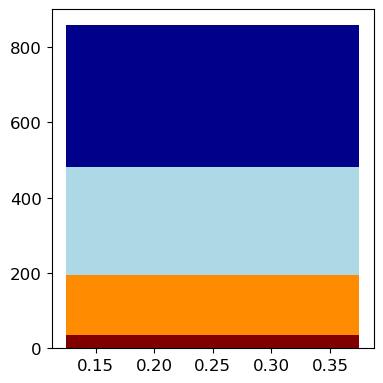

In [47]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
class_names = ['Extreme El Niño', 'CP El Niño', 'CP La Niña', 'Basin-wide La Niña',]
clrs = gmclrs[:len(gmm_order)]
# Decadel variability
bottom = np.zeros_like(stacked_occurances[0])
bottom_ = np.zeros_like(stacked_occurances_[0])
for i, stack in enumerate(stacked_occurances):
    ax.bar(0.25, stack, bottom=bottom, width=0.25, color=gmclrs[i], label=class_names[i])
    bottom += stack.data
ax.legend(loc='best', ncol=1, bbox_to_anchor=(0.48, 0.75, .52, 0.1), 
           fontsize=8, mode='expand')
for i, stack in enumerate(stacked_occurances_):
    ax.bar(0.75, stack, bottom=bottom_, width=0.25, color=gmclrs[i], label=class_names[i])
    bottom_ += stack.data
ax.set_xticks([0.25,0.75])
ax.set_xticklabels(['piControl','6ka'])
ax.set_ylabel("Occurrences")

#axs[3].axvline(np.datetime64('1970-01-01'), ls=':', color='k')
#plt.savefig("/home/gsato/latgmm/figures/Occurrences_200_no_34.pdf")

### Decadal variability

In [48]:
def rolling_window_covariance(da: xr.DataArray):
    covs = []
    times = []
    #for i in range(window_size-1, len(da['time'])):
        # Select window
    chunk = da
    # Compute covariance
    cov = np.cov(chunk.data[~np.isnan(chunk.data)])
    covs.append(cov)
    times.append(chunk['time'].data)
    
    return np.array(covs), np.array(times)


# Weights and Nino3.4 should span same time period
#nino34 = nino34.sel(time=slice("1855-12-01", None))
#weights = weights.sel(time=slice("1855-12-01", None)) 

# Weighted Nino3.4
nino34_k = []
for k in weights34['classes']:
    nino34_k.append(nino34 * weights34.sel(classes=k))
nino34_k = xr.concat(nino34_k, dim=pd.Index(weights34['classes'].data, name='classes'))

nino34_var, times = rolling_window_covariance(nino34)
nino34_k_cov = []
for i in np.arange(1,6):
    nino34_cov, times = rolling_window_covariance(nino34_k.sel(classes=i)) 
    nino34_k_cov.append(nino34_cov)
###    
nino34_k_ = []
for k in weights34_['classes']:
    nino34_k_.append(nino34_ * weights34_.sel(classes=k))
nino34_k_ = xr.concat(nino34_k_, dim=pd.Index(weights34_['classes'].data, name='classes'))

nino34_var_, times_ = rolling_window_covariance(nino34_)
nino34_k_cov_ = []
for i in range(1,6):
    nino34_cov_, times_ = rolling_window_covariance(nino34_k_.sel(classes=i)) 
    nino34_k_cov_.append(nino34_cov_)

In [49]:
stacked_lines = [(nino34_k_cov[i] / nino34_var) for i in gmm_order]
stacked_lines_ = [(nino34_k_cov_[i] / nino34_var_) for i in gmm_order_mh]

IndexError: list index out of range

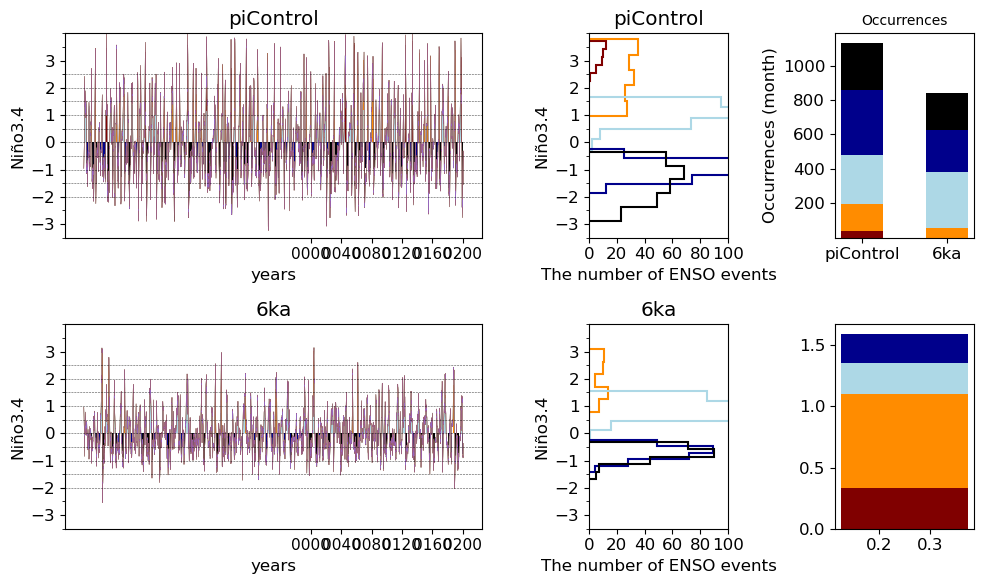

In [50]:
import matplotlib.ticker as ticker
from matplotlib.ticker import MaxNLocator,MultipleLocator,AutoMinorLocator
import datetime

labels = [rf"k={k}" for k in gmm_order]
labels_abc = ["a", "b", "c", "d", "e", "f"]
#labels.append("cov")
fig, axs = plt.subplots(2, 3, 
                        width_ratios=[3,1,1],
                        figsize=(10, 6),)
                        #sharey=True)
axs = axs.flatten()

#nrows, ncols = (2, 2)
#fig = plt.figure(figsize=(9, nrows*2.))
#gs = gridspec.GridSpec(nrows, ncols, width_ratios=[3,1], height_ratios=[2,1,2])
#axs = [fig.add_subplot(gs[0,0]), fig.add_subplot(gs[0,1])]
#axs.append(fig.add_subplot(gs[1,0]))#, sharex=axs[0]))
#axs.append(fig.add_subplot(gs[2,0]))#, sharex=axs[0]))
#axs.append(fig.add_subplot(gs[1:,1]))

# Nino34 time-series and hisplot
#im, bins, _ = axs[1].hist(nino34.data, bins='auto', density=True, orientation='horizontal',
 #                         histtype='bar', color='k', alpha=.5)#, label="piControl")
#im_, bins_, _ = axs[3].hist(nino34_.data, bins='auto', density=True, orientation='horizontal',
 #                         histtype='bar', color='k', alpha=.5)#, label="6ka")
bins=5
    
for i, k in enumerate(gmm_order):
    n34_k = nino34 * weights34.sel(classes=k+1)
    idx_nonzero = np.where(weights34.sel(classes=k+1).data > 0.5)[0]
    n34_k = n34_k[idx_nonzero]
    axs[0].bar(n34_k['time'].data, height=n34_k.data, width=4e2,
                   color=gmclrs[i], alpha=.8)
    axs[0].plot(date_modified_mean,#nino_indices["nino34"]["time"], 
                nino34_mean, linewidth=0.2) #nino_indices["nino34"]#.rolling(time=3, center=True).mean()
    axs[0].set_title("piControl")
    axs[1].sharey(axs[0])
    axs[1].hist(n34_k.data, bins=bins, density=False, orientation='horizontal',
                histtype='step', color=gmclrs[i], linewidth=1.5, #alpha=.4,
                label="_nolegend_")#class_names[i])
#                label=r'$p(c_{k}|z_t) \cdot y$'.replace('k', str(k+1)))
    axs[1].set_title('piControl')

for i, k in enumerate(gmm_order_mh):
    n34_k_ = nino34_ * weights34_.sel(classes=k+1)
    idx_nonzero_ = np.where(weights34_.sel(classes=k+1).data > 0.5)[0]
    n34_k_ = n34_k_[idx_nonzero_]
    axs[3].sharex(axs[0])
    axs[3].bar(n34_k_["time"].data, height=n34_k_.data, width=4e2,
                   color=gmclrs[i], alpha=.8)#, label=rf'$p(c={k}|z_t) \cdot y$')
    axs[3].plot(date_modified_mean_mh,#nino_indices_["nino34"]["time"], 
                nino34_mean_mh, linewidth=0.2) #nino_indices_["nino34"]#.rolling(time=3, center=True).mean()
    axs[3].set_title('6ka')
    axs[4].sharey(axs[3])
    axs[4].hist(n34_k_.data, bins=bins, density=False, orientation='horizontal',
                histtype='step', color=gmclrs[i], linewidth=1.5, #alpha=.4,
               )#label=class_names[i])
    axs[4].set_title('6ka')

for n in range(2):
    for i in np.arange(-5,5):
        axs[3*n].axhline(y=-0.5*i, c="black", linewidth=0.4, alpha=0.7, linestyle="--")
    axs[3*n].set_xlabel("years")
    axs[3*n].set_ylabel("Niño3.4")
    #axs[2*n].xaxis.set_major_locator(mticker.MaxNLocator(nbins=10))
    #axs[3*n].set_xticklabels(["0", "$1\pi$", "$2\pi$", "$3\pi$", "$4\pi$"])
    axs[3*n].tick_params(axis='x', rotation=0, labelsize=11)
    axs[3*n].set_ylim(-3.5,4)
    axs[3*n].set_yticks(ticks=np.arange(-3,3.1,1))
    axs[3*n].yaxis.set_minor_locator(ticker.AutoMinorLocator(n=2))
    axs[3*n].tick_params(axis='y', rotation=0, labelsize=12)
    axs[3*n+1].set_xlabel("The number of ENSO events")
    axs[3*n+1].set_ylabel("Niño3.4")
    axs[3*n+1].set_xticks(np.arange(0,101,20))
    axs[3*n+1].set_xlim(0,100)
    axs[3*n+1].tick_params(axis='y', rotation=0, labelsize=12)
    axs[3*n+1].yaxis.set_tick_params(labelleft=True) 
    #axs[2*n+1].legend(bbox_to_anchor=(1., .1, .6, 1.), loc="lower left", ncol=1)
    
# Suppose your data has a datetime index
time = np.array(date_modified_mean)#.values   # or your own time array
time_ = np.array(date_modified_mean_mh)
n_ticks = 9  # total ticks (including first and last)

# Select indices for evenly spaced ticks
#tick_idx = np.linspace(84, len(time)-12, n_ticks, dtype=int)#
#tick_locs = time[tick_idx]
#tick_idx_ = np.linspace(0, len(time_)-12, n_ticks, dtype=int)
#tick_locs_ = time[tick_idx_]
#axs[0].set_xticks(tick_locs)
xticks = [datetime.datetime(2000, 1, 1, 0, 0), datetime.datetime(2040, 1, 1, 0, 0), 
          datetime.datetime(2080, 1, 1, 0, 0), datetime.datetime(2120, 1, 1, 0, 0),
          datetime.datetime(2160, 1, 1, 0, 0), datetime.datetime(2200, 1, 1, 0, 0)]
axs[0].set_xticks(xticks)
axs[0].set_xticklabels(["0000", "0040", "0080", "0120", "0160", "0200"])
import matplotlib.gridspec as gridspec

clrs = gmclrs[:len(gmm_order)]
clrs.append('lightgrey')

# occurrence 
class_names = ['Extreme El Niño', 'CP El Niño', 'CP La Niña', 'Basin-wide La Niña',]
clrs = gmclrs[:len(gmm_order)]
# Decadel variability
bottom = np.zeros_like(stacked_occurances[0])
bottom_ = np.zeros_like(stacked_occurances_[0])
for i, stack in enumerate(stacked_occurances):
    axs[2].bar(0.25, stack, bottom=bottom, width=0.25, color=gmclrs[i])#, label=class_names[i])
    bottom += stack.data
#axs[2].legend(loc='best', ncol=1, bbox_to_anchor=(0.48, 0.75, .52, 0.1), 
#           fontsize=8, mode='expand')
for i, stack in enumerate(stacked_occurances_):
    axs[2].bar(0.75, stack, bottom=bottom_, width=0.25, color=gmclrs[i])#, label=class_names[i])
    bottom_ += stack.data
axs[2].set_xticks([0.25,0.75])
axs[2].set_xticklabels(['piControl','6ka'])
axs[2].set_ylabel("Occurrences (month)")
axs[2].set_title('Occurrences', fontsize=10)

# Decadel variability
bottom = np.zeros_like(stacked_lines[0]*nino34_var)#nino34_k_cov[0]
bottom_ = np.zeros_like(stacked_lines_[0]*nino34_var_)#stacked_lines_[0]
for i, stack in enumerate(stacked_lines):#nino34_k_cov
    axs[5].bar(0.25, stack*nino34_var, bottom=bottom, width=0.25, color=clrs[i], label=class_names[i])
    bottom += (stack.data)*nino34_var
#axs[5].legend(loc='best', ncol=1, bbox_to_anchor=(0.55, 0.90, 0.45, 0.1), fontsize=8, mode='expand')
for i, stack_ in enumerate(stacked_lines_):#_
    axs[5].bar(0.75, stack_*nino34_var_, bottom=bottom_, width=0.25, color=clrs[i], label="_nolegend_")#class_names[i])
    bottom_ += (stack_.data)*nino34_var_
axs[5].set_ylim(0,3.0)    
axs[5].set_ylabel(r"Variances")
axs[5].set_xticks([0.25,0.75])
axs[5].set_xticklabels(['piControl','6ka'])
axs[5].set_title('Variances\n   [4 ENSO categories]', fontsize=10)
   
fig.legend(loc='upper center', ncol=4, bbox_to_anchor=(0.07, 0.97, .9, 0.1), 
           fontsize=12, mode='expand')
for i in np.arange(0,6):
    if i in [0, 3]:
        axs[i].text(datetime.datetime(1990, 12, 1, 0, 0), 4.2, labels_abc[i], #transform=axs[i, j].transAxes,
                       fontsize=12, fontweight='bold')
    elif i == 2:
        axs[i].text(0.075, 500, labels_abc[i], #transform=axs[i, j].transAxes,
                       fontsize=12, fontweight='bold')
    elif i == 5:
        axs[i].text(0.075, 3.1, labels_abc[i], #transform=axs[i, j].transAxes,
                       fontsize=12, fontweight='bold')
    else:
        axs[i].text(0, 4.2, labels_abc[i], #transform=axs[i, j].transAxes,
                       fontsize=12, fontweight='bold')
#gpl.enumerate_subplots(axs, pos_x=0.00, pos_y=1.05, fontsize=12)
#plt.savefig("/home/gsato/latgmm/figures/clusters_timeseries_variances_200_SST.pdf")

In [56]:
# variances in piControl
stacked_lines*nino34_var

array([[0.95288735],
       [0.48715191],
       [0.27931641],
       [0.43066408]])

In [57]:
# variances in 6ka
stacked_lines_*nino34_var_

array([[0.19083708],
       [0.30424763],
       [0.11628213],
       [0.13203679]])

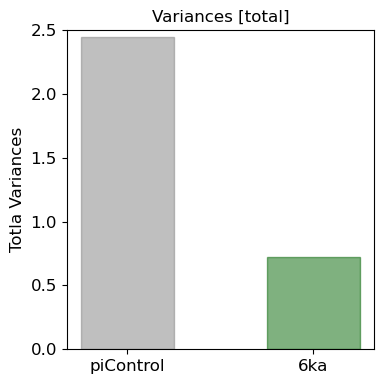

In [55]:
# total variances
fig, axs = plt.subplots(1, 1, figsize=(4, 4))
variance = nino34_var#.sel(time=years, method='nearest')
variance_ = nino34_var_
#axs[2].plot(nino34_var['time'], nino34_var, color='darkgreen',
#           label=r'$\sigma_{30y}$ (Nino3.4)')
#axs[2].fill_between(nino34_var['time'], np.zeros(len(nino34_var['time'])), nino34_var, color='darkgreen', alpha=.5)
axs.bar(0.25, height=variance,  color='gray', edgecolor='gray', alpha=.5, width=0.25)
axs.bar(0.75, height=variance_,  color='darkgreen', edgecolor='darkgreen', alpha=.5, width=0.25)
axs.set_ylim(0,2.5)
axs.set_ylabel(r"Totla Variances")
axs.set_xticks([0.25,0.75])
axs.set_xticklabels(['piControl','6ka'])
axs.set_title('Variances [total]', fontsize=12)
plt.savefig("/home/gsato/latgmm/figures/clusters_total_variances_200_SST_no_34.pdf")

### store ENSO months as a netcdf

In [56]:
### cluster times (500 years)
print(gmm_order)
# Step 1: Select datetime values
# extreme El Nino
extreme_times = nino34["time"].values[np.where(weights34.sel(classes=5).data > 0.5)[0]]
extreme_times_2 = nino34["time"].values[np.where(weights34.sel(classes=3).data > 0.5)[0]]
extreme_times_mh = nino34_["time"].values[np.where(weights34_.sel(classes=3).data > 0.5)[0]]
# CP El Nino
cpel_times = nino34["time"].values[np.where(weights34.sel(classes=4).data > 0.5)[0]]
cpel_times_mh = nino34_["time"].values[np.where(weights34_.sel(classes=4).data > 0.5)[0]]
# CP La Nina
cpla_times = nino34["time"].values[np.where(weights34.sel(classes=2).data > 0.5)[0]]
cpla_times_mh = nino34_["time"].values[np.where(weights34_.sel(classes=2).data > 0.5)[0]]
# Basin-wide La Nina
ba_times = nino34["time"].values[np.where(weights34.sel(classes=1).data > 0.5)[0]]
ba_times_mh = nino34_["time"].values[np.where(weights34_.sel(classes=1).data > 0.5)[0]]

# Step 2: convert to cftime NoLeap
import cftime
def convert_to_cf(date_data):
    
    # convert datetime64[ns] to datetime.datetime
    dt_list = [pd.Timestamp(t).to_pydatetime() for t in date_data]
    # subtract 1300 years
    dt_list_min = [t.replace(year=t.year - 1300) for t in dt_list]
    # convert to cftime no leap
    cf_time = [cftime.DatetimeNoLeap(dt.year, dt.month, dt.day) for dt in dt_list_min]

    return cf_time

extreme_times = convert_to_cf(extreme_times)
extreme_times_2 = convert_to_cf(extreme_times_2)
extreme_times_mh = convert_to_cf(extreme_times_mh)
cpel_times = convert_to_cf(cpel_times)
cpel_times_mh = convert_to_cf(cpel_times_mh)
cpla_times = convert_to_cf(cpla_times)
cpla_times_mh = convert_to_cf(cpla_times_mh)
ba_times = convert_to_cf(ba_times)
ba_times_mh = convert_to_cf(ba_times_mh)

[4 2 3 1 0]


In [59]:
# Step 3: Create DataArray
extreme = xr.DataArray(
    data=extreme_times,
    dims="time",
    coords={"time": extreme_times},
    name="extreme"
).to_dataset()
extreme_2 = xr.DataArray(
    data=extreme_times_2,
    dims="time",
    coords={"time": extreme_times_2},
    name="extreme"
).to_dataset()
extreme_mh = xr.DataArray(
    data=extreme_times_mh,
    dims="time",
    coords={"time": extreme_times_mh},
    name="extreme"
).to_dataset()

cpel = xr.DataArray(
    data=cpel_times,
    dims="time",
    coords={"time": cpel_times},
    name="cpel"
).to_dataset()
cpel_mh = xr.DataArray(
    data=cpel_times_mh,
    dims="time",
    coords={"time": cpel_times_mh},
    name="cpel"
).to_dataset()

cpla = xr.DataArray(
    data=cpla_times,
    dims="time",
    coords={"time": cpla_times},
    name="cpla"
).to_dataset()
cpla_mh = xr.DataArray(
    data=cpla_times_mh,
    dims="time",
    coords={"time": cpla_times_mh},
    name="cpla"
).to_dataset()

ba = xr.DataArray(
    data=ba_times,
    dims="time",
    coords={"time": ba_times},
    name="ba"
).to_dataset()
ba_mh = xr.DataArray(
    data=ba_times_mh,
    dims="time",
    coords={"time": ba_times_mh},
    name="ba"
).to_dataset()

In [62]:
extreme_new = xr.concat([extreme, extreme_2], dim="time")

In [65]:
# Step 4: Save
extreme_new.to_netcdf("/groups/XDU5/Go/research_data/latgmm/extreme_pi_500.nc")
extreme_mh.to_netcdf("/groups/XDU5/Go/research_data/latgmm/extreme_mh_500.nc")
cpel.to_netcdf("/groups/XDU5/Go/research_data/latgmm/cpel_pi_500.nc")
cpel_mh.to_netcdf("/groups/XDU5/Go/research_data/latgmm/cpel_mh_500.nc")
cpla.to_netcdf("/groups/XDU5/Go/research_data/latgmm/cpla_pi_500.nc")
cpla_mh.to_netcdf("/groups/XDU5/Go/research_data/latgmm/cpla_mh_500.nc")
ba.to_netcdf("/groups/XDU5/Go/research_data/latgmm/ba_pi_500.nc")
ba_mh.to_netcdf("/groups/XDU5/Go/research_data/latgmm/ba_mh_500.nc")

In [60]:
# Step 1: Select datetime values
# extreme El Nino
extreme_times = nino34["time"].values[np.where(weights34.sel(classes=3).data > 0.5)[0]]
extreme_times_mh = nino34_["time"].values[np.where(weights34_.sel(classes=3).data > 0.5)[0]]
# CP El Nino
cpel_times = nino34["time"].values[np.where(weights34.sel(classes=4).data > 0.5)[0]]
cpel_times_mh = nino34_["time"].values[np.where(weights34_.sel(classes=4).data > 0.5)[0]]
# CP La Nina
cpla_times = nino34["time"].values[np.where(weights34.sel(classes=2).data > 0.5)[0]]
cpla_times_mh = nino34_["time"].values[np.where(weights34_.sel(classes=2).data > 0.5)[0]]
# Basin-wide La Nina
ba_times = nino34["time"].values[np.where(weights34.sel(classes=1).data > 0.5)[0]]
ba_times_mh = nino34_["time"].values[np.where(weights34_.sel(classes=1).data > 0.5)[0]]

# Step 2: convert to cftime NoLeap
import cftime
def convert_to_cf(date_data):
    
    # convert datetime64[ns] to datetime.datetime
    dt_list = [pd.Timestamp(t).to_pydatetime() for t in date_data]
    # subtract 1300 years
    dt_list_min = [t.replace(year=t.year - 1300) for t in dt_list]
    # convert to cftime no leap
    cf_time = [cftime.DatetimeNoLeap(dt.year, dt.month, dt.day) for dt in dt_list_min]

    return cf_time

extreme_times = convert_to_cf(extreme_times)
extreme_times_mh = convert_to_cf(extreme_times_mh)
cpel_times = convert_to_cf(cpel_times)
cpel_times_mh = convert_to_cf(cpel_times_mh)
cpla_times = convert_to_cf(cpla_times)
cpla_times_mh = convert_to_cf(cpla_times_mh)
ba_times = convert_to_cf(ba_times)
ba_times_mh = convert_to_cf(ba_times_mh)

In [61]:
# Step 3: Create DataArray
extreme = xr.DataArray(
    data=extreme_times,
    dims="time",
    coords={"time": extreme_times},
    name="extreme"
).to_dataset()
extreme_mh = xr.DataArray(
    data=extreme_times_mh,
    dims="time",
    coords={"time": extreme_times_mh},
    name="extreme"
).to_dataset()

cpel = xr.DataArray(
    data=cpel_times,
    dims="time",
    coords={"time": cpel_times},
    name="cpel"
).to_dataset()
cpel_mh = xr.DataArray(
    data=cpel_times_mh,
    dims="time",
    coords={"time": cpel_times_mh},
    name="cpel"
).to_dataset()

cpla = xr.DataArray(
    data=cpla_times,
    dims="time",
    coords={"time": cpla_times},
    name="cpla"
).to_dataset()
cpla_mh = xr.DataArray(
    data=cpla_times_mh,
    dims="time",
    coords={"time": cpla_times_mh},
    name="cpla"
).to_dataset()

ba = xr.DataArray(
    data=ba_times,
    dims="time",
    coords={"time": ba_times},
    name="ba"
).to_dataset()
ba_mh = xr.DataArray(
    data=ba_times_mh,
    dims="time",
    coords={"time": ba_times_mh},
    name="ba"
).to_dataset()

# Step 4: Save
extreme.to_netcdf("/groups/XDU5/Go/research_data/latgmm/extreme_pi.nc")
extreme_mh.to_netcdf("/groups/XDU5/Go/research_data/latgmm/extreme_mh.nc")
cpel.to_netcdf("/groups/XDU5/Go/research_data/latgmm/cpel_pi.nc")
cpel_mh.to_netcdf("/groups/XDU5/Go/research_data/latgmm/cpel_mh.nc")
cpla.to_netcdf("/groups/XDU5/Go/research_data/latgmm/cpla_pi.nc")
cpla_mh.to_netcdf("/groups/XDU5/Go/research_data/latgmm/cpla_mh.nc")
ba.to_netcdf("/groups/XDU5/Go/research_data/latgmm/ba_pi.nc")
ba_mh.to_netcdf("/groups/XDU5/Go/research_data/latgmm/ba_mh.nc")

### ### Supplementary ### ###

### Alternative way of EOF transformation

In [ ]:
pcgmm_storer = {}
eof_projections = ["iCESM"]
n_components = 10

for projection in eof_projections:
    print(f"Projection: {projection}")
    ds4eof = dset_pi.sel(lat=slice(-31,33),lon=slice(130, -70))
    sppca = eof.SpatioTemporalPCA(ds4eof, n_components=n_components)
    print(f"Explained variance: {np.sum(sppca.explained_variance())}")
    #if projection in ["CESM2", "CESM2 [10S,10N]"]:
        #sppca.pca.components_[0,:] = -sppca.pca.components_[0,:]
    
    eofs = sppca.get_eofs()
    # Save EOFs and PCs
    pcgmm_storer[projection] = dict(
        sppca=sppca,
        eofs=eofs,)

In [ ]:
# draw the EOFs

print("iCESM variances: ",pcgmm_storer["iCESM"]["sppca"].explained_variance())

fig, ax = plt.subplots(nrows=3,ncols=2, gridspec_kw={'height_ratios': [1, 3, 3]},
                       subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)},
                           figsize=(11,8))
ax = ax.flatten()
clevs = np.arange(-0.05,0.06,0.005)
for i,projection in enumerate(eof_projections):
    storer = pcgmm_storer[projection]
    var = storer["eofs"]["ssta"]

    # Plot PCs time series
    s = storer["sppca"].get_principal_components()
    ax[i] = fig.add_subplot(3, 2, i+1)
    ax[i].set_box_aspect(0.27)
    for pc in range(2):
        ax[i].plot(s[:,pc],label=f"PC {pc}")
        ax[i].legend()
        ax[i].axhline(0, color='black', linestyle='--', linewidth=1)
        ax[i].set_title("PCs SSTA [K]", fontsize=10)

    # Plot EOFs
    for n in range(n_components):
        eof_map =  var[n,:,:]
        im = ax[2*(n+1)+i].pcolormesh(storer["eofs"]["lon"], storer["eofs"]["lat"], eof_map, 
                                  transform=ccrs.PlateCarree(), 
                                  vmin=clevs.min(), vmax=clevs.max(),
                                  cmap='seismic')#add_bar=False)#, **plparam)
        # Define the xticks for longitude
        ax[2*(n+1)+i].set_xticks(np.arange(130,291,20), crs=ccrs.PlateCarree())
        lon_formatter = cticker.LongitudeFormatter()
        ax[2*(n+1)+i].xaxis.set_major_formatter(lon_formatter)
        ax[2*(n+1)+i].tick_params(axis='x', rotation=30)#, labelsize=8)

        # Define the yticks for latitude
        ax[2*(n+1)+i].set_yticks(np.arange(-30,31,10), crs=ccrs.PlateCarree())
        lat_formatter = cticker.LatitudeFormatter()
        ax[2*(n+1)+i].yaxis.set_major_formatter(lat_formatter)
        ax[2*(n+1)+i].set_title(f"EOF {n+1}", fontsize=10)

    # Draw the colorbar
        cx = fig.colorbar(im,ax=ax[2*(n+1)+i],orientation='vertical',extend="both", 
                        shrink=0.45,label='Surface Temp. [K]')

### Check how to reconstruct PCs and EOFs

In [ ]:
# method 1
a = pcgmm_storer["iCESM"]["sppca"].get_principal_components()

# method 2
from numpy import linalg as LA
ds4eof = dset_pi.sel(lat=slice(-31,33),lon=slice(130, -70))
idx_notNaN = np.ma.masked_invalid(ds4eof["ssta"]).filled(0.)
nt,ny,nx = idx_notNaN.shape
X = np.reshape(idx_notNaN,(nt,ny*nx))
C = np.cov(X,rowvar=False)
eigenvalues_v1,eigenvectors_v1=LA.eig(C)
PC1 = np.dot(X,eigenvectors_v1[:,0:2])
eof1 = np.reshape(eigenvectors_v1[:,0],(ny,nx))

In [ ]:
PC_pi = np.dot(X,eigenvectors_v1)
PC_mh = np.empty(shape=(len(PC_pi[:,0]), len(PC_pi[0,:])), dtype='object')
for i in np.arange(0,len(PC_pi[:,0])):   #2400 time steps
    for j in np.arange(0, len(PC_pi[0,:])):
        if PC_pi[i,j] == 0:
            PC_mh[i,j] = 0
        else:
            PC_mh[i,j] = PC_pi[i,j] - PC_pi[i,:].mean()   #first row to the last row

In [ ]:
# check both methods can produce the same time series and spatial SSTA

fig,ax = plt.subplots(3,1,figsize=(11,5.5))
ax[0].plot(PC1/np.std(PC1))
#ax[0].plot(a[:,0])

land_mask = np.isnan(ds4eof["ssta"][0,:,:].values)  # True where land exists
fixed = eof1
fixed[land_mask] = np.nan
ax[1].contourf(fixed)
ax[2].contourf(pcgmm_storer["iCESM"]["eofs"]["ssta"].sel(eof=0))